# Comparación de modelos para demanda por estación

Objetivo: comparar Random Forest y XGBoost para predecir la demanda por estación en una serie temporal, respetando split temporal train/val/test.

La variable objetivo es la demanda estimada por estación y horario: `demand`.
Se evaluarán ambos modelos con la misma métrica de regresión (R², RMSE, MAE, MAPE) para que sean comparables.
No usamos accuracy porque este no es un problema de clasificación; es un problema de regresión y pronóstico temporal.

In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor

from pulso_transmi import PulsoTransmiClient

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
client = PulsoTransmiClient()
stations = client.stations()
observations = client.observations_dataframe(page_size=5000)
context = client.context_dataframe(page_size=5000)

df = observations.merge(context, on="observed_at", how="left").merge(stations, on="station_id", how="left")
df["observed_at"] = pd.to_datetime(df["observed_at"]).dt.tz_localize(None)
df = df.sort_values("observed_at").reset_index(drop=True)

# Variables temporales
df["hour"] = df["observed_at"].dt.hour
df["day_of_week"] = df["observed_at"].dt.dayofweek
df["month"] = df["observed_at"].dt.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Lags y rolling para captar estacionalidad horaria y diaria
for lag in [1, 2, 3, 6, 12, 24]:
    df[f"lag_{lag}"] = df.groupby("station_id")["demand"].shift(lag)

for window in [3, 6, 12, 24]:
    df[f"rolling_mean_{window}"] = (
        df.groupby("station_id")["demand"]
        .transform(lambda s: s.shift(1).rolling(window, min_periods=1).mean())
    )

df["demand_log1p"] = np.log1p(df["demand"])

for col in [c for c in df.columns if c.startswith("lag_") or c.startswith("rolling_mean_")]:
    df[col] = df[col].fillna(df[col].median())

print("Data preparado:", df.shape)
print(df[["station_id", "observed_at", "demand", "hour", "day_of_week", "month"]].head())

Data preparado: (51840, 27)
  station_id         observed_at  demand  hour  day_of_week  month
0      02300 2026-07-26 05:00:00      56     5            6      7
1      10009 2026-07-26 05:00:00     251     5            6      7
2      09122 2026-07-26 05:00:00      59     5            6      7
3      09000 2026-07-26 05:00:00      81     5            6      7
4      07107 2026-07-26 05:00:00      39     5            6      7


In [3]:
target = "demand"
categorical_features = ["station_id", "corridor"]
numeric_features = [
    "rain_mm", "rain_forecast", "temperature_c", "temperature_forecast", "event_intensity",
    "hour", "day_of_week", "month", "is_weekend",
] + [f"lag_{lag}" for lag in [1, 2, 3, 6, 12, 24]] + [f"rolling_mean_{window}" for window in [3, 6, 12, 24]]

features = categorical_features + numeric_features

train_end = int(len(df) * 0.70)
val_end = int(len(df) * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

X_train = train_df[features]
y_train = train_df[target]
X_val = val_df[features]
y_val = val_df[target]
X_test = test_df[features]
y_test = test_df[target]

print(f"train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")
print(f"target median train: {y_train.median():.2f}")

train=36288, val=7776, test=7776
target median train: 262.00


In [4]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            numeric_features,
        ),
    ],
    remainder="drop",
)

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-6))) * 100
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred),
        "mape_pct": mape,
    }

def fit_and_score(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    metrics = regression_metrics(y_val, pred)
    return model, metrics, pred

print("Preparador de features listo.")

Preparador de features listo.


In [5]:
rf_grid = {
    "n_estimators": [300, 500, 700],
    "max_depth": [8, 12, None],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.8],
}

xgb_grid = {
    "n_estimators": [300, 500, 700],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

rf_results = []
for params in ParameterGrid(rf_grid):
    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                RandomForestRegressor(
                    random_state=42,
                    n_jobs=-1,
                    **params,
                ),
            ),
        ]
    )
    _, metrics, _ = fit_and_score(model, X_train, y_train, X_val, y_val)
    rf_results.append({"params": params, **metrics})

xgb_results = []
for params in ParameterGrid(xgb_grid):
    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                XGBRegressor(
                    objective="reg:squarederror",
                    random_state=42,
                    n_jobs=-1,
                    eval_metric="rmse",
                    **params,
                ),
            ),
        ]
    )
    _, metrics, _ = fit_and_score(model, X_train, y_train, X_val, y_val)
    xgb_results.append({"params": params, **metrics})

rf_best = sorted(rf_results, key=lambda x: x["r2"], reverse=True)[0]
xgb_best = sorted(xgb_results, key=lambda x: x["r2"], reverse=True)[0]

print("Mejor RF en validación:")
print(rf_best)
print("\nMejor XGBoost en validación:")
print(xgb_best)

Mejor RF en validación:
{'params': {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'n_estimators': 500}, 'mae': 44.87736611761562, 'rmse': np.float64(73.22627895301486), 'r2': 0.945499023813452, 'mape_pct': np.float64(14.323671533241376)}

Mejor XGBoost en validación:
{'params': {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 700, 'subsample': 0.8}, 'mae': 45.61968231201172, 'rmse': np.float64(74.32682920091843), 'r2': 0.9438484907150269, 'mape_pct': np.float64(14.510393880667225)}


In [6]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1,
                **rf_best["params"],
            ),
        ),
    ]
)

xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBRegressor(
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1,
                eval_metric="rmse",
                **xgb_best["params"],
            ),
        ),
    ]
)

rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

rf_pred_test = rf_model.predict(X_test)
xgb_pred_test = xgb_model.predict(X_test)

rf_metrics_test = regression_metrics(y_test, rf_pred_test)
xgb_metrics_test = regression_metrics(y_test, xgb_pred_test)

print("Evaluación en test para Random Forest:")
print(rf_metrics_test)
print("\nEvaluación en test para XGBoost:")
print(xgb_metrics_test)

Evaluación en test para Random Forest:
{'mae': 45.89194563515191, 'rmse': np.float64(73.37120823761246), 'r2': 0.9496070134582719, 'mape_pct': np.float64(13.967666023693996)}

Evaluación en test para XGBoost:
{'mae': 46.653011322021484, 'rmse': np.float64(74.54532427385202), 'r2': 0.9479812979698181, 'mape_pct': np.float64(14.299581627723226)}


In [7]:
test_predictions = test_df[["station_id", "observed_at", target]].copy()
test_predictions["rf_pred"] = rf_pred_test
test_predictions["xgb_pred"] = xgb_pred_test

station_summary = (
    test_predictions.groupby("station_id", as_index=False)
    .agg(
        demanda_real=("demand", "mean"),
        rf_pred_promedio=("rf_pred", "mean"),
        xgb_pred_promedio=("xgb_pred", "mean"),
    )
)

station_summary["delta_rf"] = station_summary["rf_pred_promedio"] - station_summary["demanda_real"]
station_summary["delta_xgb"] = station_summary["xgb_pred_promedio"] - station_summary["demanda_real"]

print("Predicciones promedio por estación en test (12 estaciones):")
print(station_summary.sort_values("station_id").round(2).to_string(index=False))

Predicciones promedio por estación en test (12 estaciones):
station_id  demanda_real  rf_pred_promedio  xgb_pred_promedio  delta_rf  delta_xgb
     02300        310.60            307.46         306.790009     -3.14      -3.81
     03000        269.08            268.14         267.369995     -0.94      -1.70
     05000        347.66            347.69         345.829987      0.03      -1.84
     05100        609.14            600.59         600.380005     -8.55      -8.76
     06000        522.62            520.06         520.900024     -2.57      -1.72
     06111        251.51            252.71         251.059998      1.20      -0.45
     07105        283.05            283.33         280.369995      0.28      -2.68
     07107        298.49            296.37         293.839996     -2.12      -4.65
     07111        700.61            693.20         693.770020     -7.41      -6.84
     09000        223.61            225.41         222.020004      1.80      -1.59
     09122        259.37   

## Comparación final

Para comparar Random Forest y XGBoost en un problema de regresión, la métrica más importante es la misma para ambos modelos:
- R²: explica cuánto de la variabilidad explica el modelo; cuanto más alto, mejor.
- RMSE: cuánto se equivocan las predicciones en unidades de demanda; cuanto más bajo, mejor.
- MAE: error promedio absoluto; más bajo, mejor.
- MAPE: error porcentual relativo.

No usamos accuracy porque `accuracy` está pensado para clasificación, no para demanda continua.

Se toma como mejor modelo el que tenga mejor R² en test y además menor RMSE/MAE.

      modelo    rmse     mae     r2  mape_pct
RandomForest 73.3712 45.8919 0.9496   13.9677
     XGBoost 74.5453 46.6530 0.9480   14.2996

Modelo ganador: RandomForest


/tmp/ipykernel_25596/3497170029.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison, x="modelo", y="r2", ax=axes[0], palette="viridis")
/tmp/ipykernel_25596/3497170029.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison, x="modelo", y="rmse", ax=axes[1], palette="magma")


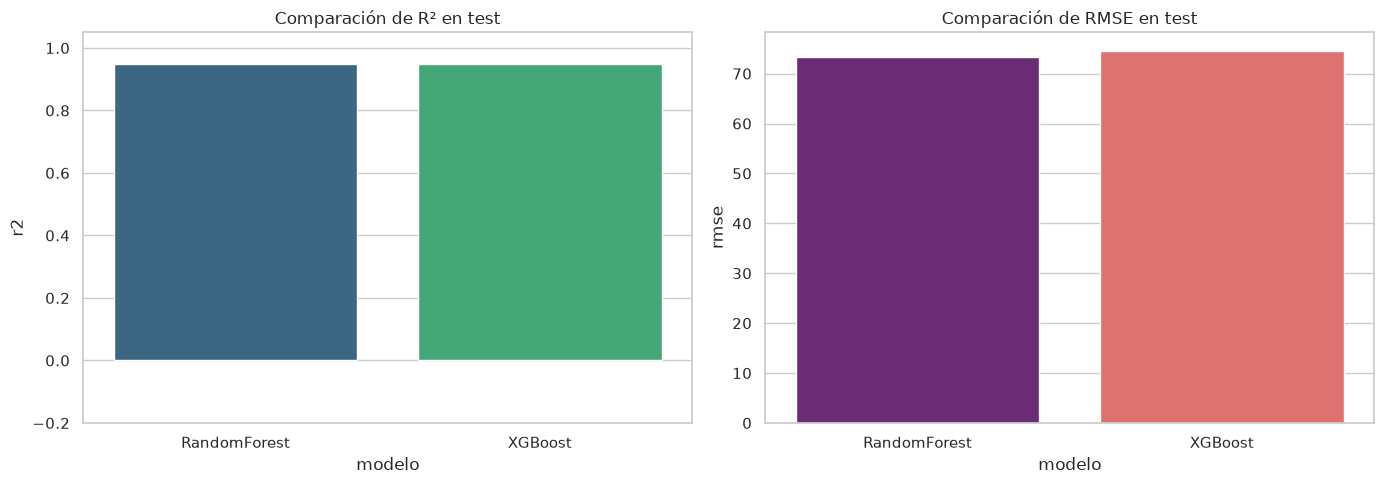

In [ ]:
comparison = pd.DataFrame(
    {
        "modelo": ["RandomForest", "XGBoost"],
        "rmse": [rf_metrics_test["rmse"], xgb_metrics_test["rmse"]],
        "mae": [rf_metrics_test["mae"], xgb_metrics_test["mae"]],
        "r2": [rf_metrics_test["r2"], xgb_metrics_test["r2"]],
        "mape_pct": [rf_metrics_test["mape_pct"], xgb_metrics_test["mape_pct"]],
    }
)

comparison = comparison.sort_values("r2", ascending=False)
print(comparison.round(4).to_string(index=False))

best_model = comparison.iloc[0]["modelo"]
print(f"\nModelo ganador: {best_model}")

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=comparison, x="modelo", y="r2", hue="modelo", palette="viridis", dodge=False, ax=axes[0], legend=False)
axes[0].set_title("Comparación de R² en test")
axes[0].set_ylim(min(comparison["r2"].min() - 0.05, -0.2), max(comparison["r2"].max() + 0.05, 1.05))

sns.barplot(data=comparison, x="modelo", y="rmse", hue="modelo", palette="magma", dodge=False, ax=axes[1], legend=False)
axes[1].set_title("Comparación de RMSE en test")
plt.tight_layout()
plt.show()